# Task 1: Restaurant Rating Prediction

### Objective
Develop a Linear Regression model to predict restaurant aggregate ratings using restaurant features.

## Step 1: Import Required Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
import os
os.getcwd()

'C:\\Users\\megha\\OneDrive\\Desktop\\Cognifyz_ML_Internship'

In [38]:
import os
os.listdir("Dataset")

['Dataset.csv.csv']

## Step 2: Load the Dataset

In [7]:
df = pd.read_csv("Dataset/Dataset.csv.csv")

## Step 3: Explore the Dataset

In [8]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [9]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [11]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


## Step 4: Data Preprocessing

In [12]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [14]:
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

In [15]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [17]:
df.dtypes

Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

In [18]:
df = df.drop([
    'Restaurant ID',
    'Restaurant Name',
    'Address',
    'Locality',
    'Locality Verbose'
], axis=1)

In [19]:
df.columns

Index(['Country Code', 'City', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [39]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [21]:
df.head()

,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,162,73,121.027535,14.565443,920,1100,0,1,0,0,0,3,4.8,0,1,314
1,162,73,121.014101,14.553708,1111,1200,0,1,0,0,0,3,4.5,0,1,591
2,162,75,121.056831,14.581404,1671,4000,0,1,0,0,0,4,4.4,1,5,270
3,162,75,121.056475,14.585318,1126,1500,0,0,0,0,0,4,4.9,0,1,365
4,162,75,121.057508,14.584450,1122,1500,0,1,0,0,0,4,4.8,0,1,229


## Step 4: Feature Selection

In [22]:
X = df.drop('Aggregate rating', axis=1)
y = df['Aggregate rating']

In [23]:
print(X.shape)
print(y.shape)

(9551, 15)
(9551,)


## Step 5: Split the Dataset into Training and Testing Sets

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7640, 15)
(1911, 15)
(7640,)
(1911,)


## Step 6: Train the Linear Regression Model

In [26]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Step 7: Predict Restaurant Ratings

In [28]:
y_pred = model.predict(X_test)
y_pred[:10]

array([1.23205355, 2.78748203, 2.93536967, 2.24474189, 1.24748576,
       1.44006317, 3.31421891, 1.2810215 , 1.97479559, 2.97144253])

In [29]:
y_pred = model.predict(X_test)

y_pred[:10]

array([1.23205355, 2.78748203, 2.93536967, 2.24474189, 1.24748576,
       1.44006317, 3.31421891, 1.2810215 , 1.97479559, 2.97144253])

## Step 8: Model Evaluation

In [40]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 1.2957102918279122
R2 Score: 0.4307345134418481


## Step 9: Feature Importance Analysis

In [31]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)
feature_importance

,Feature,Coefficient
8,Has Online delivery,6.825585e-01
11,Price range,5.495970e-01
7,Has Table booking,9.916204e-03
0,Country Code,6.587436e-03
2,Longitude,1.872754e-03
14,Votes,6.480180e-04
3,Latitude,5.692925e-04
5,Average Cost for two,9.296040e-07
10,Switch to order menu,1.665335e-16
4,Cuisines,-1.889879e-04


## Step 10: Compare Actual and Predicted Ratings

In [42]:
results = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred
})
results.head(10)

,Actual Rating,Predicted Rating
0,2.1,1.232054
1,4.1,2.787482
2,3.2,2.935370
3,4.4,2.244742
4,3.5,1.247486
5,0.0,1.440063
6,3.2,3.314219
7,0.0,1.281022
8,3.6,1.974796
9,4.0,2.971443


## Step 11: Visualization

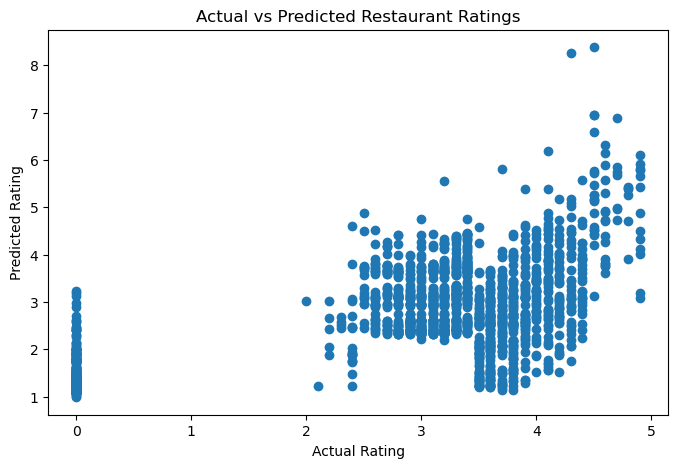

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Restaurant Ratings")
plt.show()

## Step 12: Final Results

In [34]:
print("Restaurant Rating Prediction Model Completed Successfully")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Restaurant Rating Prediction Model Completed Successfully
Mean Squared Error: 1.2957
R² Score: 0.4307


# Task 1 Summary

**Status:**  Completed ✅

The restaurant rating prediction model was successfully developed using Linear Regression. The dataset was preprocessed, the model was trained and evaluated, and the most influential features affecting restaurant ratings were identified.

**Model Performance**
- **Mean Squared Error (MSE):** 1.2957
- **R² Score:** 0.4307

**Conclusion:** The developed model achieved moderate predictive performance and provides a reliable baseline for restaurant rating prediction.